# Importaciones Necesarias

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
# SKPipeline para sub-pipelines (num / cat) que no llevan samplers
from sklearn.pipeline import Pipeline as SKPipeline
from sklearn.base import TransformerMixin
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder, PolynomialFeatures
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree                                  # necesario para tree.plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score, classification_report,
    confusion_matrix, roc_curve, roc_auc_score,
    precision_recall_curve, auc, average_precision_score
)
# ImbPipeline soporta pasos de muestreo (samplers) entre el preprocesador y el clasificador
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler, TomekLinks, EditedNearestNeighbours, AllKNN
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.combine import SMOTETomek, SMOTEENN


# Lectura de los datos

In [37]:
datos = pd.read_csv('student_dropout_dataset_v3.csv')
drop_cols = ["Student_ID", "Dropout"]

X = datos.drop(columns=drop_cols)
y = datos['Dropout']

X['Semester'] = X['Semester'].str[-1].astype(int)

In [38]:
num_cols = ["Age", "Family_Income", "Study_Hours_per_Day", "Attendance_Rate", 
            "Assignment_Delay_Days", "Travel_Time_Minutes", "Stress_Index", 
            "GPA", "Semester_GPA", "CGPA", "Semester"]

cat_cols = ["Department", "Gender", "Internet_Access",
            "Parental_Education", "Part_Time_Job", "Scholarship"]

# Resumen de los datos

In [39]:
resumenEntrada = X.describe()
resumenSalida = y.describe()
print(resumenEntrada)
print(resumenSalida)

               Age  Family_Income  Study_Hours_per_Day  Attendance_Rate  \
count  10000.00000    9500.000000          9500.000000      10000.00000   
mean      21.02606   38377.247474             4.014592         81.73683   
std        2.13981   20496.232179             1.295450          8.22093   
min       17.00000   25000.000000             0.500000         38.20000   
25%       19.50000   25000.000000             3.160000         76.40000   
50%       21.00000   29740.500000             4.000000         81.80000   
75%       22.50000   44520.000000             4.870000         87.30000   
max       29.60000  316601.000000             8.980000        100.00000   

       Assignment_Delay_Days  Travel_Time_Minutes  Stress_Index           GPA  \
count           10000.000000          10000.00000   9500.000000  10000.000000   
mean                1.799700             30.17926      5.507147      2.308440   
std                 1.344307             11.91887      1.765951      1.061717   


Variables con valores faltantes:

In [40]:
X.isnull().sum()

Age                        0
Gender                     0
Family_Income            500
Internet_Access            0
Study_Hours_per_Day      500
Attendance_Rate            0
Assignment_Delay_Days      0
Travel_Time_Minutes        0
Part_Time_Job              0
Scholarship                0
Stress_Index             500
GPA                        0
Semester_GPA               0
CGPA                       0
Semester                   0
Department                 0
Parental_Education       511
dtype: int64

# Gráficas para mostrar datos:

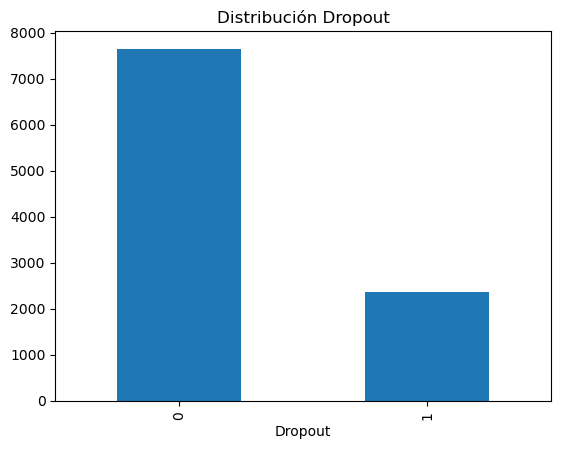

In [41]:
# Gráfica que muestra la distribución de dropout

y.value_counts().plot(kind="bar")
plt.title("Distribución Dropout")
plt.show()

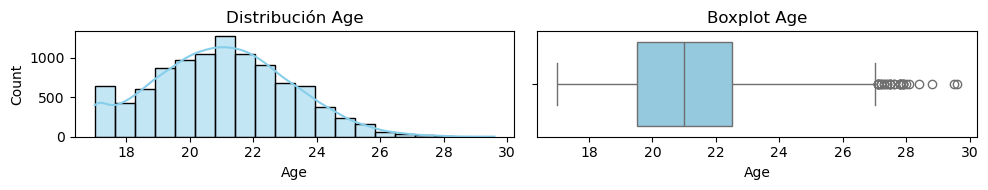

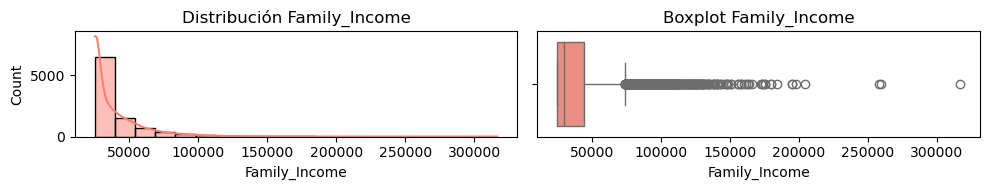

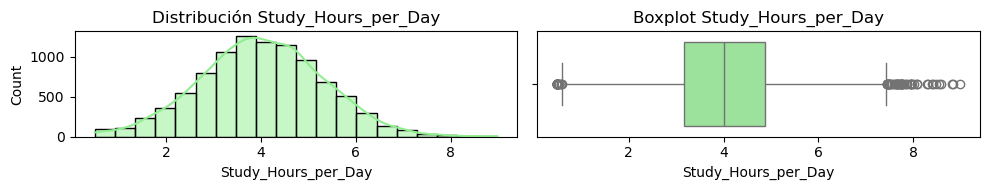

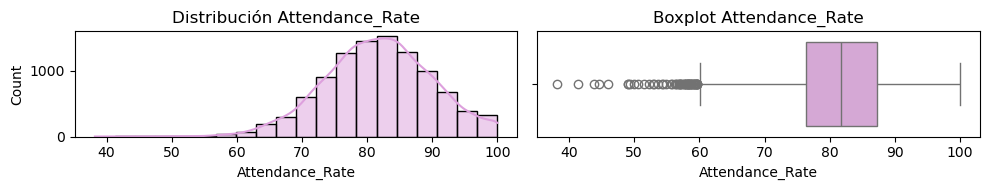

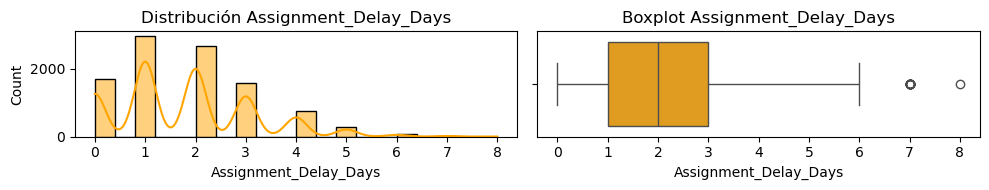

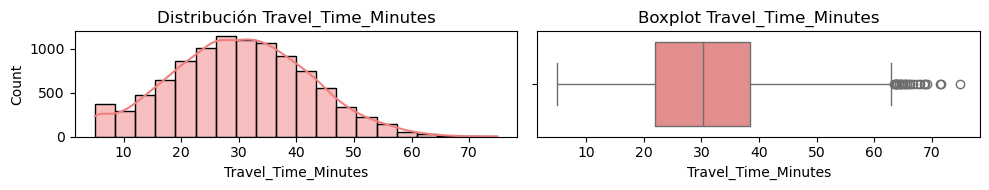

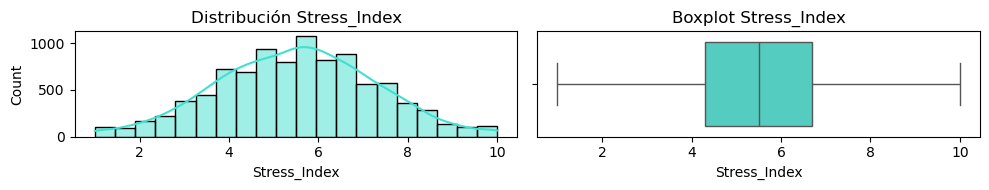

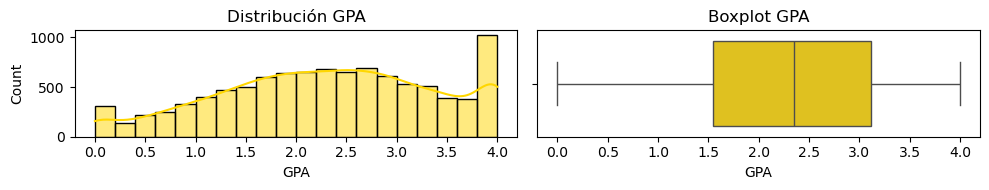

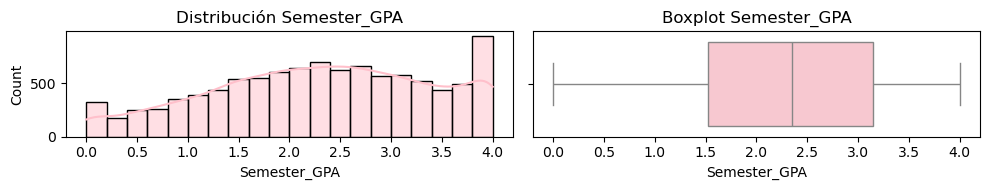

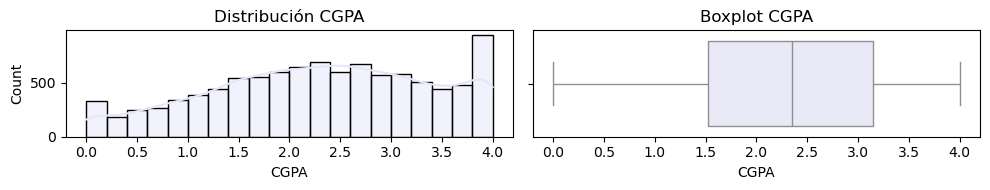

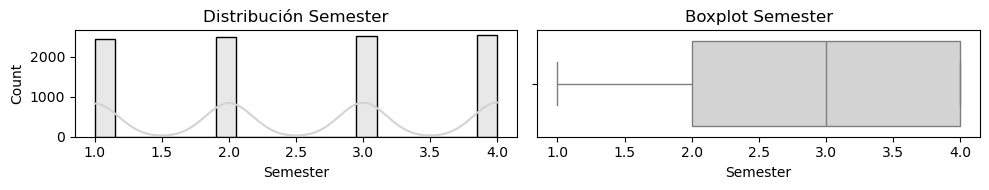

In [42]:
num_cols = ["Age", "Family_Income", "Study_Hours_per_Day", "Attendance_Rate", 
            "Assignment_Delay_Days", "Travel_Time_Minutes", "Stress_Index", 
            "GPA", "Semester_GPA", "CGPA", "Semester"]

colors = ["skyblue", "salmon", "lightgreen", "plum", "orange", 
          "lightcoral", "turquoise", "gold", "pink", "lavender", "lightgray"]

for col, color in zip(num_cols, colors):
    fig, axes = plt.subplots(1, 2, figsize=(10, 2))
    
    sns.histplot(data=X, x=col, bins=20, kde=True, color=color, ax=axes[0])
    axes[0].set_title(f"Distribución {col}")
    
    sns.boxplot(data=X, x=col, color=color, ax=axes[1])
    axes[1].set_title(f"Boxplot {col}")
    
    plt.tight_layout()
    plt.show()

# Distribución de clases para cada variable:

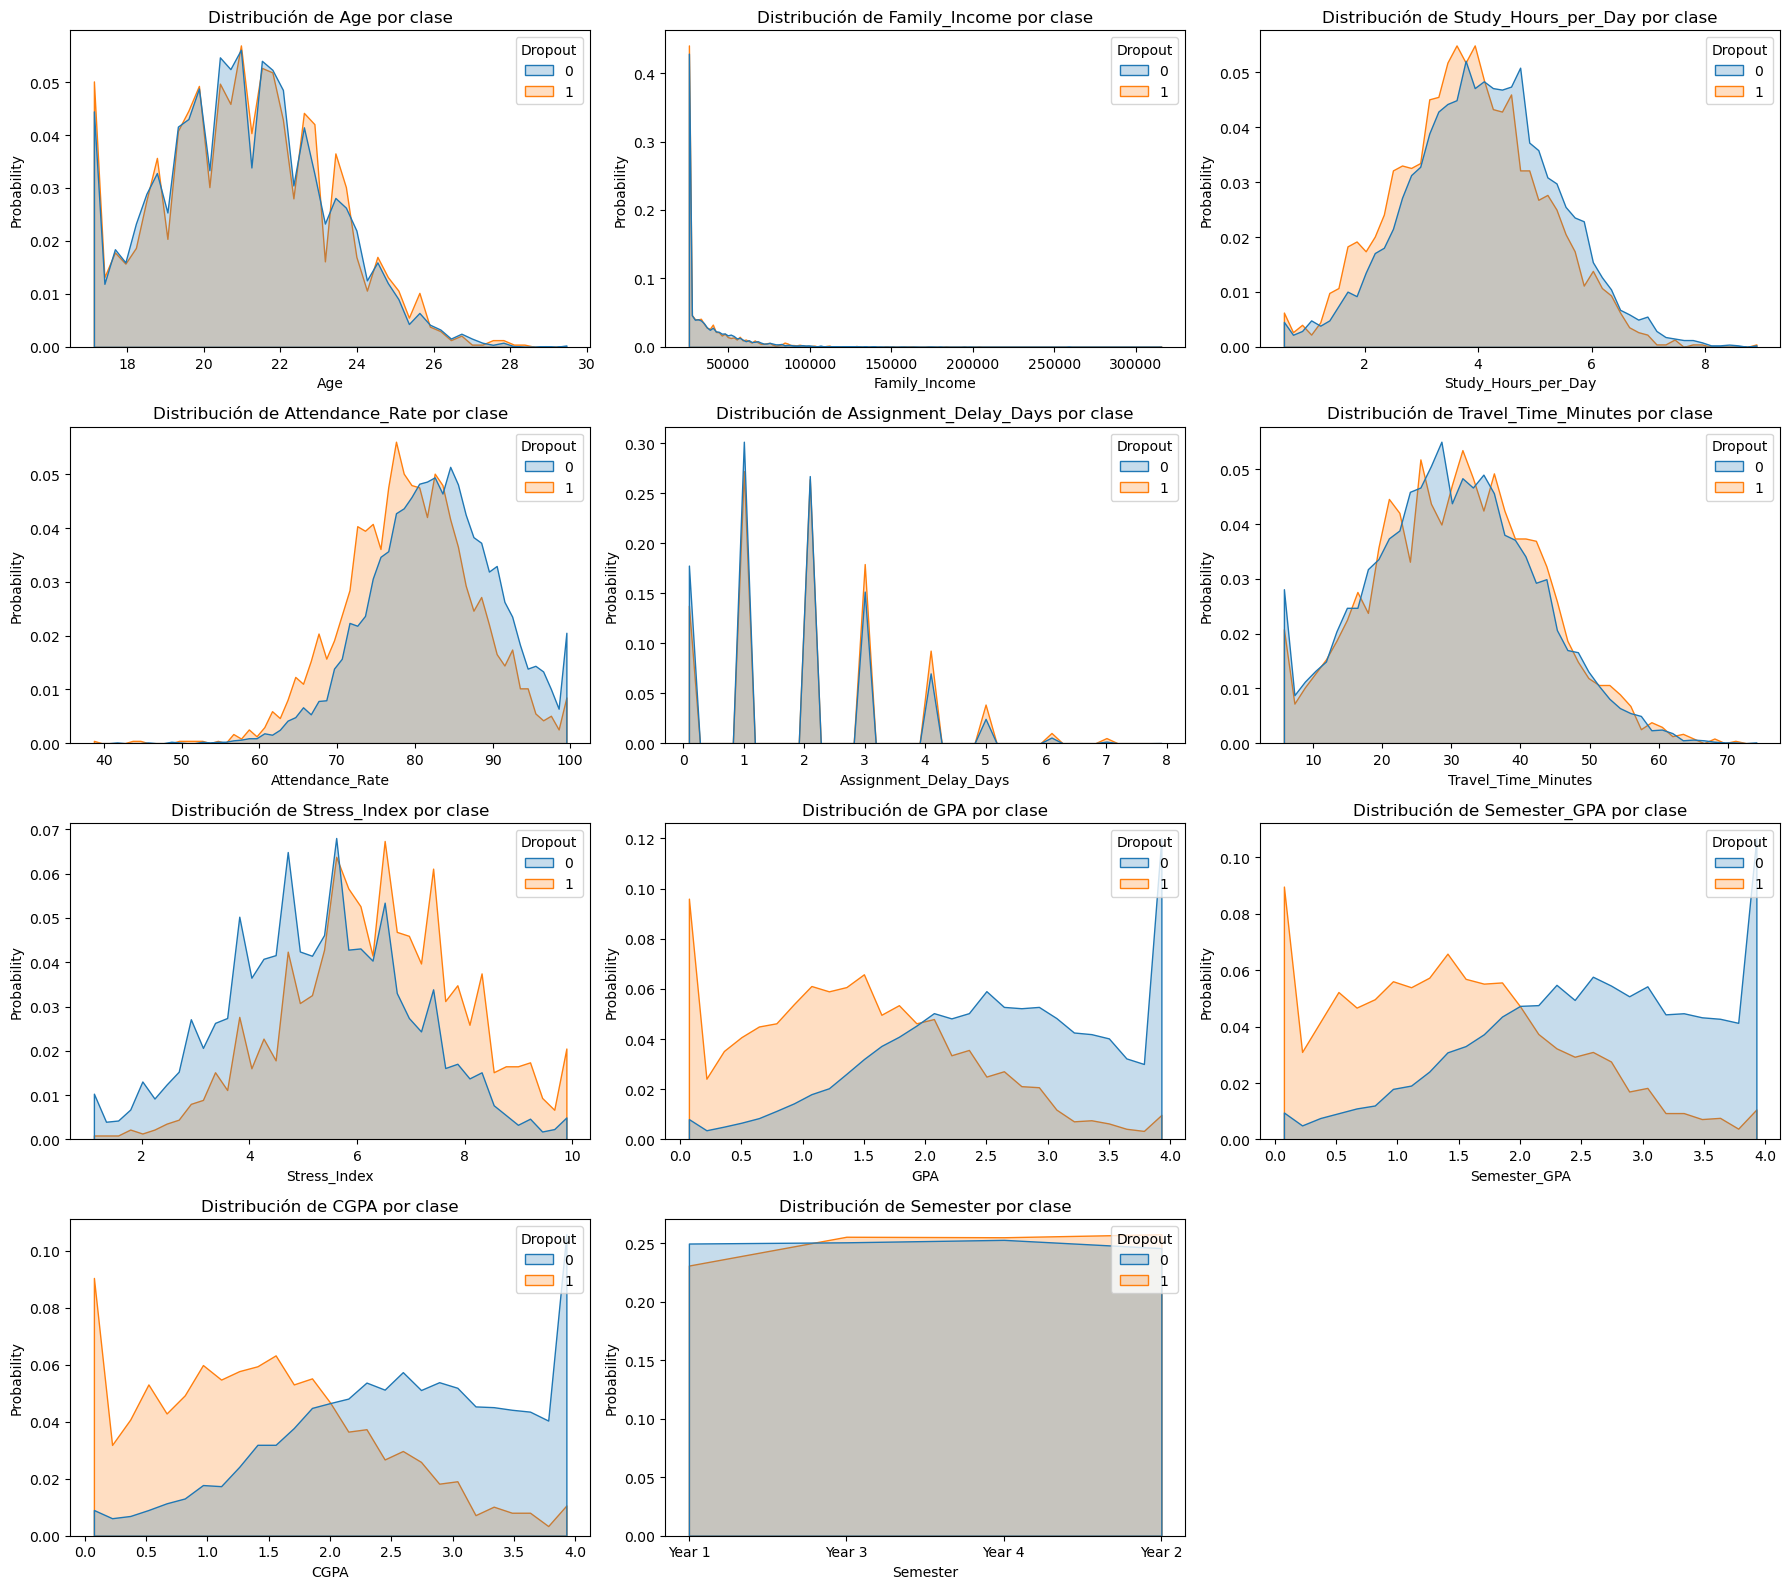

In [43]:
n_cols = 3
n_rows = 4

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, columna in enumerate(num_cols):
    sns.histplot(
        data=datos,
        x=columna,
        hue="Dropout",
        element='poly',
        stat='probability',
        common_norm=False,
        ax=axes[i]
    )
    axes[i].set_title(f"Distribución de {columna} por clase")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# Distribución de variables categoricas con Dropout

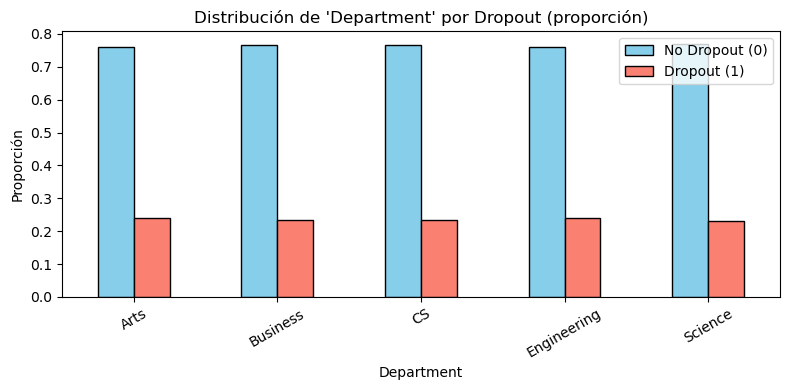

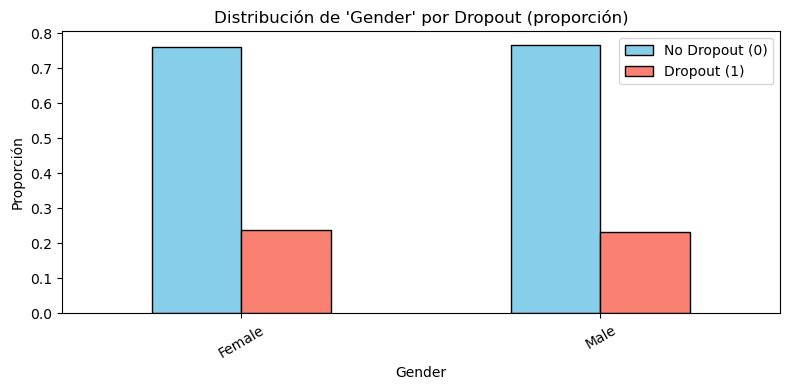

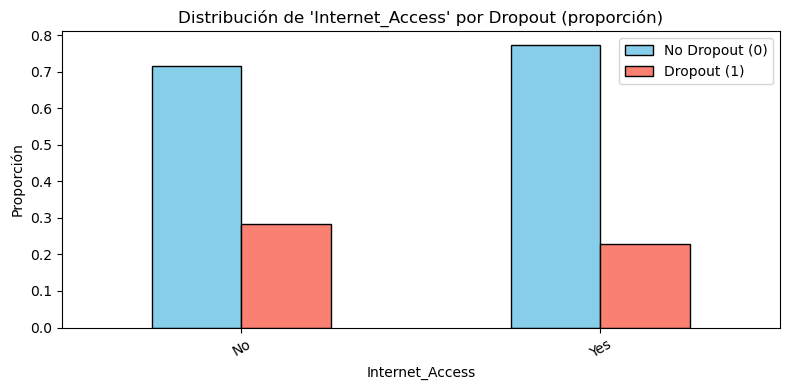

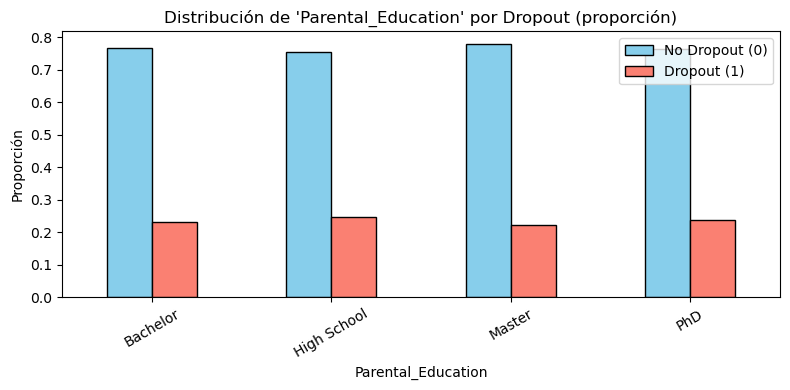

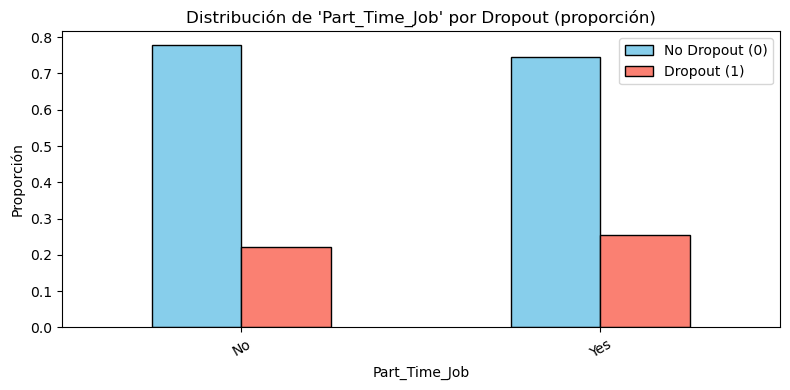

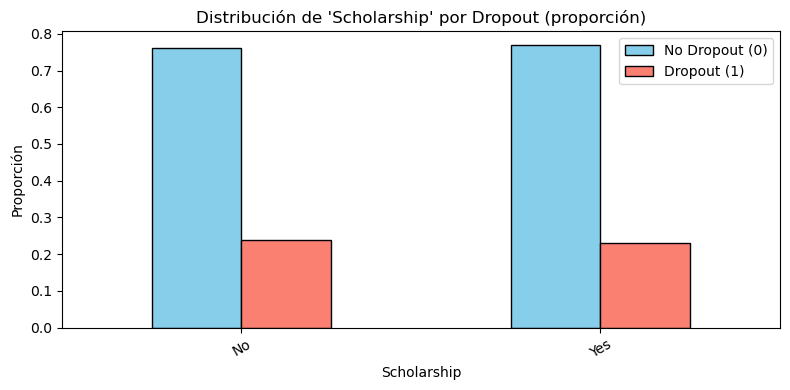

In [44]:

cat_cols_plot = ["Department", "Gender", "Internet_Access","Parental_Education", "Part_Time_Job", "Scholarship"]

for col in cat_cols_plot:
    fig, ax = plt.subplots(figsize=(8, 4))

    tabla = datos.groupby([col, "Dropout"]).size().unstack(fill_value=0)
    tabla_norm = tabla.div(tabla.sum(axis=1), axis=0)
    tabla_norm.plot(kind="bar", ax=ax, color=["skyblue", "salmon"], edgecolor="black")
    ax.set_title(f"Distribución de '{col}' por Dropout (proporción)")
    ax.set_xlabel(col)
    ax.set_ylabel("Proporción")
    ax.legend(["No Dropout (0)", "Dropout (1)"])
    ax.tick_params(axis='x', rotation=30)
    
    plt.tight_layout()
    plt.show()

# Correlación entre variables numéricas y la variable de salida:

Dropout                  1.000000
Stress_Index             0.255648
Assignment_Delay_Days    0.082327
Travel_Time_Minutes      0.028080
Semester                 0.010658
Age                      0.007585
Family_Income           -0.011123
Study_Hours_per_Day     -0.089376
Attendance_Rate         -0.163539
CGPA                    -0.444807
Semester_GPA            -0.445396
GPA                     -0.460352
Name: Dropout, dtype: float64


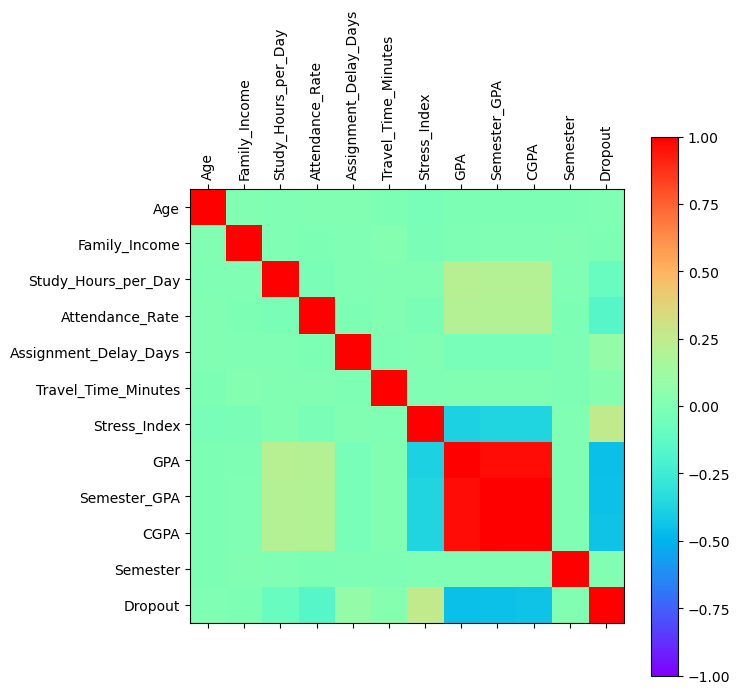

In [45]:
X_num = X[num_cols].copy()
X_num["Dropout"] = y
# Cálculo de la matriz de correlaciones con la función corr de pandas
correlaciones = X_num.corr()
print(correlaciones["Dropout"].sort_values(ascending=False))

# Mostramos la matriz de correlaciones especificando el rango de los valores [-1, 1]
fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111)
cax = ax.matshow(correlaciones, vmin=-1, vmax=1, cmap=plt.cm.rainbow)
fig.colorbar(cax)
ticks = np.arange(0,len(X_num.columns),1)
ax.set_xticks(ticks)
ax.set_yticks(ticks)
# Añadimos los nombres de las variables en la figura
names = X_num.columns
ax.set_xticklabels(names, rotation='vertical')
ax.set_yticklabels(names)
plt.show()

# Correlación entre cada variable categórica y la variable objetivo:  
Mediante Cramer   

In [46]:

cat_cols = X.columns.difference(num_cols)

def cramers_v(X, y):
    tabla = pd.crosstab(X, y)
    chi2 = chi2_contingency(tabla)[0]      
    n = tabla.sum().sum()
    q = min(tabla.shape) - 1
    return np.sqrt(chi2 / (n * q))

for col in cat_cols:
    v = cramers_v(X[col], y)
    print(f"{col}: Cramér's V = {v:.4f}")


Department: Cramér's V = 0.0087
Gender: Cramér's V = 0.0070
Internet_Access: Cramér's V = 0.0428
Parental_Education: Cramér's V = 0.0216
Part_Time_Job: Cramér's V = 0.0365
Scholarship: Cramér's V = 0.0064


Las variables individualmente son independientes al dropout: no utiles a menos que haya una relación multivariable

# División de datos en conjuntos de entrenamiento, validación y test.  
Test es el 10% de los ejemplos, entrenamiento es 80% del resto (72%) y validación lo faltante (18%).

In [47]:

X_resto, X_test, y_resto, y_test = train_test_split(X, y, test_size = 0.10, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_resto, y_resto, test_size = 0.20, stratify=y_resto, random_state=42)


# Detección y tratamiento de outliers:

Detección de outliers con IQR y mediana

In [48]:
# Creamos la clase de detección y tratamiento de Outliers
class OutlierDetecion_treatment_IQR(TransformerMixin):

    # Constructor de la clase
    def __init__(self, k=1.5, columns=None):
        self.k = k
        self.columns = columns
    
    # Método fit
    def fit(self, X, y=None):
        # Transformamos X a DataFrame por si llega un array de Numpy (para compatibilidad en la Pipeline)
        X = pd.DataFrame(X)
        if self.columns is None:
            # Si no se determinan variables en el constructor si tratan todas
            self.columns = X.select_dtypes(include="number").columns
        self.stats = X[self.columns].describe()
        self.median = X[self.columns].median()

        # Devolvemos el propio objeto modificado
        return self

    # Método transform
    def transform(self, X):
        # Transformamos X a DataFrame por si llega un array de Numpy (para compatibilidad en la Pipeline)
        X = pd.DataFrame(X)
        # Creamos una copia del DataFrame X para no perder los datos originales
        Xaux = X.copy()


        # Se comprueba qué elementos están por encima y por debajo de dichos límites (máscaras de booleanos)
        Q1 = self.stats.loc['25%']   
        Q3 = self.stats.loc['75%']
        IQRs = Q3 - Q1
        limiteInf = Q1 - self.k * IQRs
        limiteSup = Q3 + self.k * IQRs  
        menores = Xaux[self.columns] < limiteInf
        mayores = Xaux[self.columns] > limiteSup

        # Se recorren las variables para detectar outliers y tratarlos (sustituir por la mediana de la variable)
        for c in self.columns:
            # obtenemos la lista de booleanos correspondientes a si los valores de los ejemplos son outliers o no para la variable c
#             indices = <RELLENAR>
            indices = np.logical_or(menores[c],mayores[c])
            # Si hay outliers
            # <RELLENAR>
            if indices.any():
                Xaux.loc[indices,c] = self.median[c]
                # Los sustituimos por la mediana
                # <RELLENAR>
        # Se devuelve el DataFrame modificado
        return Xaux
    
    # Método para asignar los valores de los híper-parámetros y que, de este modo, 
        # podamos aplicar GridSearchCV sobre un objeto de esta clase
    def set_params(self, **parameters):
        for parameter, value in parameters.items():
            setattr(self, parameter, value)
        return self
    
    # Método para obtener los valores de los híper-parámetros que queramos del modelo (lo usa GridSearchCV al mostrar la mejor configuración)
    def get_params(self, deep=True):
        # Devolvemos los valores de los híper-parámetros del método de preparación de datos
        return {"k": self.k}

Detección de outliers con media y desviación (mediana)

In [49]:
# Creamos la clase de detección y tratamiento de Outliers
class OutlierDetecion_treatment_MeanStd(TransformerMixin):

    # Constructor de la clase
    def __init__(self, k=1.5, columns=None):
        self.k = k
        self.columns = columns
    
    # Método fit
    def fit(self, X, y=None):
        # Transformamos X a DataFrame por si llega un array de Numpy (para compatibilidad en la Pipeline)
        X = pd.DataFrame(X)
        if self.columns is None:
            # Si no se determinan variables en el constructor si tratan todas
            self.columns = X.select_dtypes(include="number").columns
        self.stats = X[self.columns].describe()
        self.media = X[self.columns].mean()
        self.desviacion = X[self.columns].std()
        self.median = X[self.columns].median()
        # Devolvemos el propio objeto modificado
        return self

    # Método transform
    def transform(self, X):
        # Transformamos X a DataFrame por si llega un array de Numpy (para compatibilidad en la Pipeline)
        X = pd.DataFrame(X)
        # Creamos una copia del DataFrame X para no perder los datos originales
        Xaux = X.copy()


        # Se comprueba qué elementos están por encima y por debajo de dichos límites (máscaras de booleanos)
        
        limiteInf = self.media - self.k * self.desviacion
        limiteSup = self.media + self.k * self.desviacion 
        menores = Xaux[self.columns] < limiteInf
        mayores = Xaux[self.columns] > limiteSup

        # Se recorren las variables para detectar outliers y tratarlos (sustituir por la mediana de la variable)
        for c in self.columns:
            # obtenemos la lista de booleanos correspondientes a si los valores de los ejemplos son outliers o no para la variable c
#             indices = <RELLENAR>
            indices = np.logical_or(menores[c],mayores[c])
            # Si hay outliers
            # <RELLENAR>
            if indices.any():
                Xaux.loc[indices,c] = self.median[c]
                # Los sustituimos por la mediana
                # <RELLENAR>
        # Se devuelve el DataFrame modificado
        return Xaux
    
    # Método para asignar los valores de los híper-parámetros y que, de este modo, 
        # podamos aplicar GridSearchCV sobre un objeto de esta clase
    def set_params(self, **parameters):
        for parameter, value in parameters.items():
            setattr(self, parameter, value)
        return self
    
    # Método para obtener los valores de los híper-parámetros que queramos del modelo (lo usa GridSearchCV al mostrar la mejor configuración)
    def get_params(self, deep=True):
        # Devolvemos los valores de los híper-parámetros del método de preparación de datos
        return {"k": self.k}

Mismos Detectores de Outliers pero reemplazando por extremos:

In [50]:
class OutlierDetecion_treatment_IQR_Extremos(TransformerMixin):

    def __init__(self, k=1.5, columns=None):
        self.k = k
        self.columns = columns
    
    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        if self.columns is None:
            # Seleccionamos solo variables numéricas
            self.columns = X.select_dtypes(include="number").columns
        
        # Calculamos estadísticos solo de las variables numéricas
        self.stats = X[self.columns].describe(percentiles=[0.25, 0.75])
        return self

    def transform(self, X):
        X = pd.DataFrame(X)
        Xaux = X.copy()

        IQRs      = self.stats.loc["75%", :] - self.stats.loc["25%", :]
        limiteInf = self.stats.loc["25%", :] - self.k * IQRs
        limiteSup = self.stats.loc["75%", :] + self.k * IQRs

        # Iteramos por las variables numéricas
        for c in self.columns:
            Xaux[c] = Xaux[c].astype(float)
            mask_low  = Xaux[c] < limiteInf[c]
            mask_high = Xaux[c] > limiteSup[c]
            if mask_low.any():
                Xaux.loc[mask_low,  c] = limiteInf[c]
            if mask_high.any():
                Xaux.loc[mask_high, c] = limiteSup[c]

        return Xaux
    
    def set_params(self, **parameters):
        for parameter, value in parameters.items():
            setattr(self, parameter, value)
        return self
    
    def get_params(self, deep=True):
        return {"k": self.k, "columns": self.columns}
    
    from sklearn.base import TransformerMixin


class OutlierDetecion_treatment_MeanStd_Extremos(TransformerMixin):
    
    # Añadimos el parámetro columns al constructor
    def __init__(self, k=2, columns=None):
        self.k = k
        self.columns = columns

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        if self.columns is None:
            # Seleccionamos solo variables numéricas
            self.columns = X.select_dtypes(include="number").columns
            
        # Calculamos media y desviación SOLO de las numéricas
        self.mean_ = X[self.columns].mean()
        self.std_  = X[self.columns].std()
        return self
    
    def transform(self, X):
        Xaux = pd.DataFrame(X).copy()
        
        limiteInf = self.mean_ - self.k * self.std_
        limiteSup = self.mean_ + self.k * self.std_
        
        # Iteramos SOLO por las variables numéricas
        for c in self.columns:
            Xaux[c] = Xaux[c].astype(float)
            mask_low  = Xaux[c] < limiteInf[c]
            mask_high = Xaux[c] > limiteSup[c]
            
            if mask_low.any():
                Xaux.loc[mask_low,  c] = limiteInf[c]
            if mask_high.any():
                Xaux.loc[mask_high, c] = limiteSup[c]
        
        return Xaux
    
    def set_params(self, **parameters):
        for parameter, value in parameters.items():
            setattr(self, parameter, value)
        return self
    
    def get_params(self, deep=True):
        return {"k": self.k, "columns": self.columns}

# Nuevas Variables Numéricas

In [51]:
class FeatureConstruction(TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        Xaux = pd.DataFrame(X).copy()
        Xaux.columns = Xaux.columns.astype(str)  # primero normalizar nombres
        
        Xaux['GPA_Drop'] = Xaux['9'] - Xaux['8']   # CGPA - Semester_GPA
        Xaux['Risk_Index'] = Xaux['6'] * Xaux['4']   # Stress * Delay
        Xaux['Study_Efficiency'] = Xaux['7'] / (Xaux['2'] + 1)  # GPA / (Hours+1)
        return Xaux

    def get_params(self, deep=True):
        return {}



# Log Transformer

In [52]:
class LogTransformer(TransformerMixin):
    def __init__(self, columns=None):
        self.columns = columns

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        X.columns = X.columns.astype(str)
        if self.columns is None:
            self.columns = list(X.columns)
        return self

    def transform(self, X):
        Xaux = pd.DataFrame(X).copy()
        Xaux.columns = Xaux.columns.astype(str) 
        for v in self.columns:
            Xaux[f'log_{v}'] = np.log(np.abs(Xaux[v]) + 1)
        return Xaux

    def set_params(self, **parameters):
        for p, v in parameters.items():
            setattr(self, p, v)
        return self

    def get_params(self, deep=True):
        return {"columns": self.columns}

# Selección de variables  

* Análisis de correlaciones

In [53]:
class corr_selection(TransformerMixin):

        # Constructor de la clase
        def __init__(self, umbral=0.9, verbose=False):
            # Umbral deseado para determinar variables correlacionadas
            self.umbral = umbral
            # Parámetro que determina si imprimir información del proceso o no
            self.verbose = verbose

        # Método fit
        def fit(self, X, y=None):
            # Transformamos X en DataFrame por si acaso llega en formato ndarray
            X = pd.DataFrame(X)
            # Calculamos la matriz de correlaciones con la función corr de pandas sobre el DataFrame con las variables de entrada X y la ponemos en valor absoluto
            correlaciones = X.corr().abs()
            # Seleccionamos el triángulo superior de la matriz de correlación
            upper = correlaciones.where(np.triu(np.ones(correlaciones.shape), k=1).astype('bool'))
            # Obtenemos los nombres de aquellas variables con correlación mayor al umbral deseado
            self.variables_a_eliminar = list(set([column for i,column in enumerate(upper.columns) if any(upper[column] > self.umbral)]))

             # Si queremos mostrar información se muestra el número de variables eliminadas y sus nombres
            if self.verbose:
                print('Se han eliminado {} variables, que son: {}'.format(len(self.variables_a_eliminar), self.variables_a_eliminar))
            # Devolvemos el objeto modificado (en este caso ha aprendido qué variables se deben eliminar al estar correlacionadas con otras)
            return self

        # Método transform
        def transform(self, X):
            # Transformamos X en DataFrame por si acaso llega en formato ndarray
            X = pd.DataFrame(X)
            # Creamos una copia del DataFrame X para no perder los datos originales
            X_uncorr = X.copy()
            # Eliminamos las variables con alta correlación con algunda de las variables de entrada
            X_uncorr.drop(self.variables_a_eliminar, axis=1, inplace=True)
            # Devolvemos el DataFrame transformado
            return X_uncorr

        # Método para asignar los valores de los híper-parámetros y que, de este modo, 
            # podamos aplicar GridSearchCV sobre un objeto de esta clase
        def set_params(self, **parameters):
            for parameter, value in parameters.items():
                setattr(self, parameter, value)
            return self

        # Método para obtener los valores de los híper-parámetros que queramos del modelo (lo usa GridSearchCV al mostrar la mejor configuración)
        def get_params(self, deep=True):
            # Devolvemos los valores de los híper-parámetros del método de preparación de datos
            return {"umbral": self.umbral}

# Pipeline con KNN


Probando bloque: outliers


,Opción,PR_AUC,Average_Precision,F1,Recall,Precision,Accuracy
0,Sin tratamiento,0.493990,0.441857,0.433666,0.358491,0.548736,0.779444
1,IQR mediana k=3,0.488757,0.437667,0.430416,0.353774,0.549451,0.779444
3,IQR extremos k=3,0.485922,0.435226,0.427350,0.353774,0.539568,0.776667
4,MeanStd extremos k=3,0.482251,0.432352,0.429587,0.356132,0.541219,0.777222
2,MeanStd mediana k=3,0.470670,0.423304,0.431818,0.358491,0.542857,0.777778



Mejor opción para outliers: Sin tratamiento  (PR-AUC=0.4940)


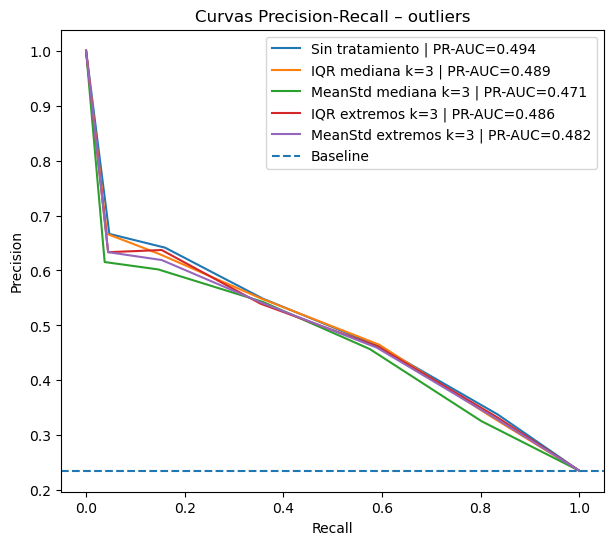


Probando bloque: imputer


,Opción,PR_AUC,Average_Precision,F1,Recall,Precision,Accuracy
2,IterativeImputer,0.497136,0.443926,0.445390,0.370283,0.558719,0.782778
0,Media,0.493990,0.441857,0.433666,0.358491,0.548736,0.779444
1,KNNImputer,0.486251,0.437080,0.439437,0.367925,0.545455,0.778889



Mejor opción para imputer: IterativeImputer  (PR-AUC=0.4971)


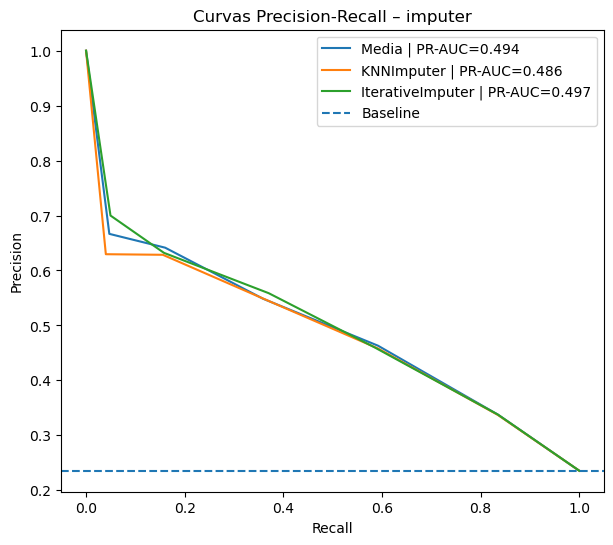


Probando bloque: new_features


,Opción,PR_AUC,Average_Precision,F1,Recall,Precision,Accuracy
1,Sí,0.501775,0.446167,0.442225,0.365566,0.559567,0.782778
0,No,0.497136,0.443926,0.445390,0.370283,0.558719,0.782778



Mejor opción para new_features: Sí  (PR-AUC=0.5018)


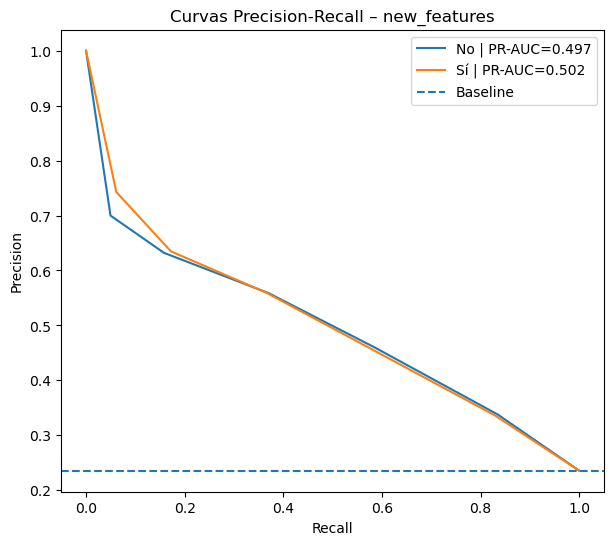


Probando bloque: log


,Opción,PR_AUC,Average_Precision,F1,Recall,Precision,Accuracy
0,No,0.501775,0.446167,0.442225,0.365566,0.559567,0.782778
1,Sí,0.494261,0.442398,0.424855,0.346698,0.548507,0.778889



Mejor opción para log: No  (PR-AUC=0.5018)


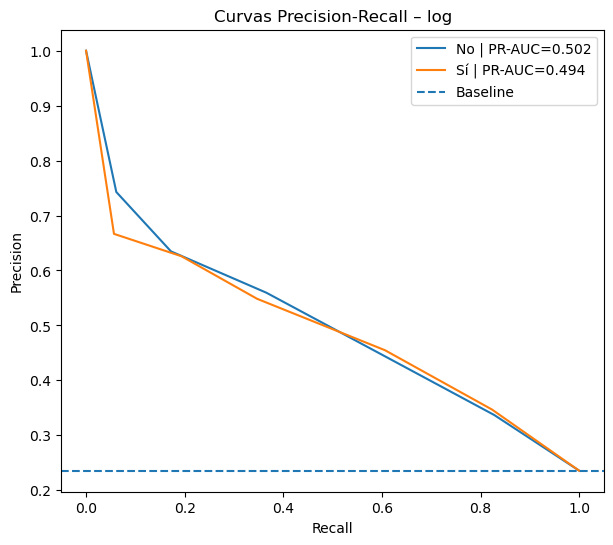


Probando bloque: corr_selector


,Opción,PR_AUC,Average_Precision,F1,Recall,Precision,Accuracy
2,Correlación umbral 0.8,0.505078,0.445002,0.427547,0.351415,0.545788,0.778333
0,No,0.501775,0.446167,0.442225,0.365566,0.559567,0.782778
1,Correlación umbral 0.9,0.495010,0.437331,0.416303,0.337264,0.543726,0.777222



Mejor opción para corr_selector: Correlación umbral 0.8  (PR-AUC=0.5051)


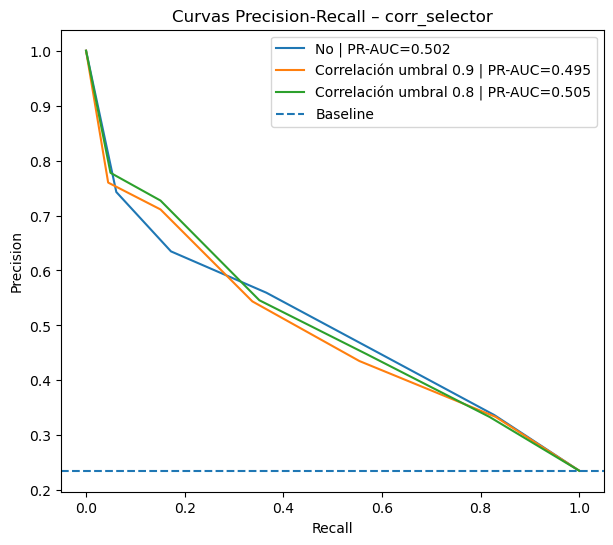


Probando bloque: scaler


,Opción,PR_AUC,Average_Precision,F1,Recall,Precision,Accuracy
0,StandardScaler,0.505078,0.445002,0.427547,0.351415,0.545788,0.778333
1,RobustScaler,0.489512,0.432755,0.423249,0.334906,0.574899,0.785000



Mejor opción para scaler: StandardScaler  (PR-AUC=0.5051)


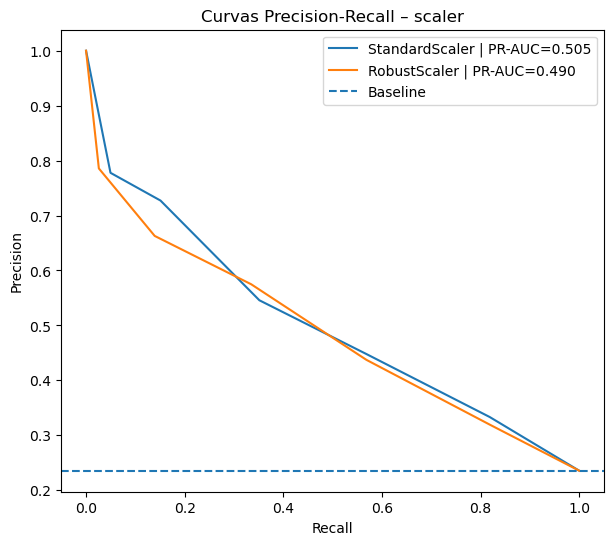


Probando bloque: selector


,Opción,PR_AUC,Average_Precision,F1,Recall,Precision,Accuracy
0,No,0.505078,0.445002,0.427547,0.351415,0.545788,0.778333
2,SelectKBest f_classif k=7,0.501497,0.446674,0.472149,0.419811,0.539394,0.778889
4,SelectKBest f_classif k=7,0.494768,0.442922,0.450899,0.384434,0.545151,0.779444
3,SelectKBest f_classif k=7,0.476426,0.434717,0.461957,0.400943,0.544872,0.780000
1,SelectKBest f_classif k=5,0.475308,0.428259,0.453189,0.393868,0.533546,0.776111



Mejor opción para selector: No  (PR-AUC=0.5051)


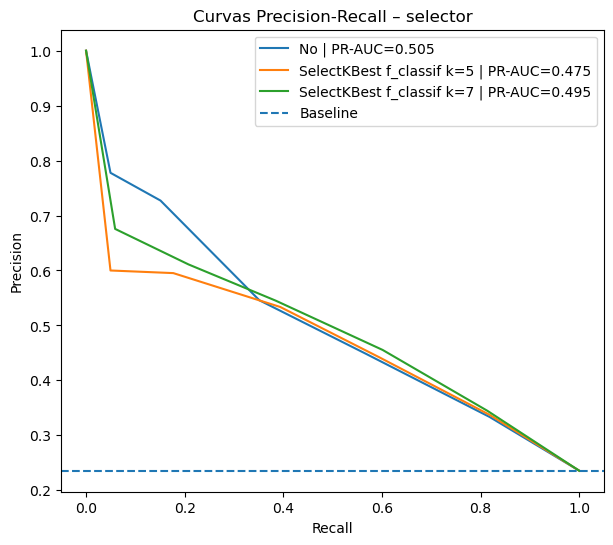

,Paso,Mejor opción,Mejor PR_AUC,Mejor F1,Mejor Recall,Mejor Precision
0,outliers,Sin tratamiento,0.493990,0.433666,0.358491,0.548736
1,imputer,IterativeImputer,0.497136,0.445390,0.370283,0.558719
2,new_features,Sí,0.501775,0.442225,0.365566,0.559567
3,log,No,0.501775,0.442225,0.365566,0.559567
4,corr_selector,Correlación umbral 0.8,0.505078,0.427547,0.351415,0.545788
5,scaler,StandardScaler,0.505078,0.427547,0.351415,0.545788
6,selector,No,0.505078,0.427547,0.351415,0.545788



CONFIGURACIÓN FINAL DEL PREPROCESAMIENTO
  outliers       : Sin tratamiento
  imputer        : IterativeImputer
  scaler         : StandardScaler
  new_features   : Sí
  log            : No
  corr_selector  : Correlación umbral 0.8
  selector       : No

Rendimiento base en validación (KNN defecto):
  PR-AUC    : 0.5051
  Accuracy  : 0.7783
  Precision : 0.5458
  Recall    : 0.3514
  F1        : 0.4275


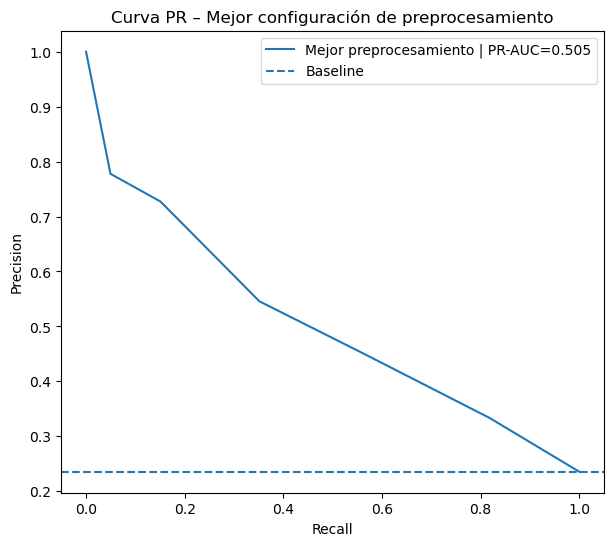

In [ ]:
from sklearn.metrics import (
    precision_recall_curve, auc, average_precision_score,
    accuracy_score, precision_score, recall_score, f1_score
)

opciones = {
    "outliers": [
        ("Sin tratamiento",         lambda: "passthrough"),
        ("IQR mediana k=3",         lambda: OutlierDetecion_treatment_IQR(k=3)),
        ("MeanStd mediana k=3",     lambda: OutlierDetecion_treatment_MeanStd(k=3)),
        ("IQR extremos k=3",        lambda: OutlierDetecion_treatment_IQR_Extremos(k=3)),
        ("MeanStd extremos k=3",    lambda: OutlierDetecion_treatment_MeanStd_Extremos(k=3)),
    ],
    "imputer": [
        ("Media",           lambda: SimpleImputer(strategy="mean")),
        ("KNNImputer",      lambda: KNNImputer(n_neighbors=5, weights="uniform")),
        ("IterativeImputer",lambda: IterativeImputer(max_iter=10, random_state=42)),
    ],
    "scaler": [
        ("StandardScaler", lambda: StandardScaler()),
        ("RobustScaler",   lambda: RobustScaler()),
    ],
    "new_features": [
        ("No",  lambda: "passthrough"),
        ("Sí",  lambda: FeatureConstruction()),
    ],
    "log": [
        ("No",  lambda: "passthrough"),
        ("Sí",  lambda: LogTransformer()),
    ],
    "corr_selector": [
        ("No",                         lambda: "passthrough"),
        ("Correlación umbral 0.9",     lambda: corr_selection(umbral=0.9)),
        ("Correlación umbral 0.8",     lambda: corr_selection(umbral=0.8)),
    ],
    "selector": [
        ("No",                          lambda: "passthrough"),
        ("SelectKBest f_classif k=7",   lambda: SelectKBest(score_func=f_classif, k=7)),
        ("SelectKBest f_classif k=10",  lambda: SelectKBest(score_func=f_classif, k=10)),
    ],
}

config_actual = {
    "outliers":     ("Sin tratamiento",  lambda: "passthrough"),
    "imputer":      ("Media",            lambda: SimpleImputer(strategy="mean")),
    "scaler":       ("StandardScaler",   lambda: StandardScaler()),
    "new_features": ("No",               lambda: "passthrough"),
    "log":          ("No",               lambda: "passthrough"),
    "corr_selector":("No",               lambda: "passthrough"),
    "selector":     ("No",               lambda: "passthrough"),
}


def crear_pipeline(config, sampler=None):
    """Construye la pipeline completa.

    Parámetros
    ----------
    config  : dict con las opciones de preprocesamiento activas.
    sampler : técnica de muestreo de imblearn (None = sin muestreo).

    Se usan SKPipeline para las sub-pipelines internas (num, cat) que no
    admiten samplers, e ImbPipeline para la pipeline principal, que sí los admite.
    """
    num_pipeline = SKPipeline(steps=[
        ("outliers",     config["outliers"][1]()),
        ("imputer",      config["imputer"][1]()),
        ("new_features", config["new_features"][1]()),
        ("log",          config["log"][1]()),
        ("corr_selector",config["corr_selector"][1]()),
        ("scaler",       config["scaler"][1]()),
    ])

    cat_pipeline = SKPipeline(steps=[
        ("imputer",  SimpleImputer(strategy="most_frequent")),
        ("encoder",  OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer(transformers=[
        ("num", num_pipeline, num_cols),
        ("cat", cat_pipeline, cat_cols)
    ])

    pasos = [("preprocessor", preprocessor)]
    if sampler is not None:
        pasos.append(("sampler", sampler))       # solo si se pasa un sampler
    pasos.append(("selector", config["selector"][1]()))
    pasos.append(("knn", KNeighborsClassifier()))

    return ImbPipeline(steps=pasos)


def evaluar_configuracion(config):
    modelo = crear_pipeline(config)
    modelo.fit(X_train, y_train)

    y_val_proba = modelo.predict_proba(X_val)[:, 1]
    y_val_pred  = modelo.predict(X_val)

    precision_curve, recall_curve, _ = precision_recall_curve(y_val, y_val_proba)
    pr_auc = auc(recall_curve, precision_curve)

    return {
        "modelo":           modelo,
        "precision_curve":  precision_curve,
        "recall_curve":     recall_curve,
        "PR_AUC":           pr_auc,
        "Average_Precision":average_precision_score(y_val, y_val_proba),
        "Accuracy":         accuracy_score(y_val, y_val_pred),
        "Precision":        precision_score(y_val, y_val_pred, zero_division=0),
        "Recall":           recall_score(y_val, y_val_pred, zero_division=0),
        "F1":               f1_score(y_val, y_val_pred, zero_division=0),
    }


def probar_paso(nombre_paso, config_actual):
    resultados, curvas = [], {}

    print(f"\n{'='*30}\nProbando bloque: {nombre_paso}\n{'='*30}")

    for nombre_opcion, factory in opciones[nombre_paso]:
        config_prueba = config_actual.copy()
        config_prueba[nombre_paso] = (nombre_opcion, factory)
        res = evaluar_configuracion(config_prueba)
        resultados.append({
            "Opción":           nombre_opcion,
            "PR_AUC":           res["PR_AUC"],
            "Average_Precision":res["Average_Precision"],
            "F1":               res["F1"],
            "Recall":           res["Recall"],
            "Precision":        res["Precision"],
            "Accuracy":         res["Accuracy"],
        })
        curvas[nombre_opcion] = (res["recall_curve"], res["precision_curve"], res["PR_AUC"])

    tabla = pd.DataFrame(resultados).sort_values("PR_AUC", ascending=False)
    display(tabla)

    mejor_opcion = tabla.iloc[0]["Opción"]
    print(f"\nMejor opción para {nombre_paso}: {mejor_opcion}  (PR-AUC={tabla.iloc[0]['PR_AUC']:.4f})")

    plt.figure(figsize=(7, 6))
    for nomb, (rc, pc, pa) in curvas.items():
        plt.plot(rc, pc, label=f"{nomb} | PR-AUC={pa:.3f}")
    plt.axhline(y=y_val.mean(), linestyle="--", label="Baseline")
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.title(f"Curvas Precision-Recall – {nombre_paso}")
    plt.legend(); plt.show()

    for nomb, factory in opciones[nombre_paso]:
        if nomb == mejor_opcion:
            config_actual[nombre_paso] = (nomb, factory)

    return config_actual, tabla


# ── Búsqueda greedy por pasos ────────────────────────────────────────────────
orden_pasos = ["outliers", "imputer", "new_features", "log", "corr_selector", "scaler", "selector"]

historial = []
for paso in orden_pasos:
    config_actual, tabla_paso = probar_paso(paso, config_actual)
    historial.append({
        "Paso":          paso,
        "Mejor opción":  config_actual[paso][0],
        "Mejor PR_AUC":  tabla_paso.iloc[0]["PR_AUC"],
        "Mejor F1":      tabla_paso.iloc[0]["F1"],
        "Mejor Recall":  tabla_paso.iloc[0]["Recall"],
        "Mejor Precision":tabla_paso.iloc[0]["Precision"],
    })

tabla_historial = pd.DataFrame(historial)
display(tabla_historial)

# Modelo con la mejor config de preprocesamiento y KNN por defecto (sin optimizar)
modelo_final = crear_pipeline(config_actual)
modelo_final.fit(X_train, y_train)

y_val_proba_base = modelo_final.predict_proba(X_val)[:, 1]
y_val_pred_base  = modelo_final.predict(X_val)

precision_curve, recall_curve, _ = precision_recall_curve(y_val, y_val_proba_base)
pr_auc_final = auc(recall_curve, precision_curve)

print("\n" + "="*40)
print("CONFIGURACIÓN FINAL DEL PREPROCESAMIENTO")
print("="*40)
for paso, valor in config_actual.items():
    print(f"  {paso:15s}: {valor[0]}")

print(f"\nRendimiento base en validación (KNN defecto):")
for k, v in [
    ("PR-AUC",    pr_auc_final),
    ("Accuracy",  accuracy_score(y_val, y_val_pred_base)),
    ("Precision", precision_score(y_val, y_val_pred_base, zero_division=0)),
    ("Recall",    recall_score(y_val, y_val_pred_base, zero_division=0)),
    ("F1",        f1_score(y_val, y_val_pred_base, zero_division=0)),
]:
    print(f"  {k:10s}: {v:.4f}")

plt.figure(figsize=(7, 6))
plt.plot(recall_curve, precision_curve, label=f"Mejor preprocesamiento | PR-AUC={pr_auc_final:.3f}")
plt.axhline(y=y_val.mean(), linestyle="--", label="Baseline")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Curva PR – Mejor configuración de preprocesamiento")
plt.legend(); plt.show()


# Resultados del Grid Search

In [57]:
tabla_res = tabla_historial[[
    "Paso", "Mejor opción", "Mejor PR_AUC", "Mejor F1", "Mejor Recall", "Mejor Precision"
]].copy()
tabla_res.columns = ["Paso", "Mejor opción", "PR-AUC", "F1", "Recall", "Precision"]
tabla_res[["PR-AUC","F1","Recall","Precision"]] = tabla_res[["PR-AUC","F1","Recall","Precision"]].round(4)
print(tabla_res.to_string(index=False))


         Paso           Mejor opción  PR-AUC     F1  Recall  Precision
     outliers        Sin tratamiento  0.4940 0.4337  0.3585     0.5487
      imputer       IterativeImputer  0.4971 0.4454  0.3703     0.5587
 new_features                     Sí  0.5018 0.4422  0.3656     0.5596
          log                     No  0.5018 0.4422  0.3656     0.5596
corr_selector Correlación umbral 0.8  0.5051 0.4275  0.3514     0.5458
       scaler         StandardScaler  0.5051 0.4275  0.3514     0.5458
     selector                     No  0.5051 0.4275  0.3514     0.5458


# Param Grid Search en KNN

In [22]:
pipeline_knn_ajustado = crear_pipeline(config_actual)

param_grid_knn = {
    "knn__n_neighbors": [3, 5, 7, 9, 11, 15, 21, 31],
    "knn__weights":     ["uniform", "distance"],
    "knn__metric":      ["euclidean", "manhattan"]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_knn = GridSearchCV(
    estimator=pipeline_knn_ajustado,
    param_grid=param_grid_knn,
    scoring="average_precision",
    cv=cv, n_jobs=-1, verbose=1
)
grid_knn.fit(X_train, y_train)

print("Mejor PR-AUC (CV):", grid_knn.best_score_)
print("Mejores parámetros KNN:", grid_knn.best_params_)

best_model_knn  = grid_knn.best_estimator_
y_val_pred_knn  = best_model_knn.predict(X_val)
y_val_proba_knn = best_model_knn.predict_proba(X_val)[:, 1]

print("\nMatriz de confusión (KNN) en validación:")
print(confusion_matrix(y_val, y_val_pred_knn))
print("\nClassification report (KNN):")
print(classification_report(y_val, y_val_pred_knn))
print("PR-AUC    :", round(average_precision_score(y_val, y_val_proba_knn), 4))
print("F1        :", round(f1_score(y_val, y_val_pred_knn, zero_division=0), 4))
print("Recall    :", round(recall_score(y_val, y_val_pred_knn, zero_division=0), 4))
print("Precision :", round(precision_score(y_val, y_val_pred_knn, zero_division=0), 4))


Fitting 5 folds for each of 32 candidates, totalling 160 fits
Mejor PR-AUC (CV): 0.5696404841928944
Mejores parámetros KNN: {'knn__metric': 'euclidean', 'knn__n_neighbors': 31, 'knn__weights': 'distance'}

Matriz de confusión (KNN) en validación:
[[1315   61]
 [ 320  104]]

Classification report (KNN):
              precision    recall  f1-score   support

           0       0.80      0.96      0.87      1376
           1       0.63      0.25      0.35       424

    accuracy                           0.79      1800
   macro avg       0.72      0.60      0.61      1800
weighted avg       0.76      0.79      0.75      1800

PR-AUC    : 0.5471
F1        : 0.3531
Recall    : 0.2453
Precision : 0.6303


# Param Grid Search en Arbol de Decision

In [59]:
# Creamos la pipeline DT reutilizando crear_pipeline y sustituyendo el paso "knn" por DT.
# Los parámetros del grid usan el prefijo "dt__" que coincide con el nuevo nombre del paso.
pipeline_dt = crear_pipeline(config_actual)
pipeline_dt.steps[-1] = ("dt", DecisionTreeClassifier(random_state=42, class_weight='balanced'))

param_grid_dt = {
    "dt__criterion":        ["gini", "entropy"],
    "dt__max_depth":        [3, 5, 10, None],
    "dt__min_samples_leaf": [1, 5, 10, 20],
    "dt__ccp_alpha":        [0.0, 0.001, 0.005, 0.01]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_dt = GridSearchCV(
    estimator=pipeline_dt,
    param_grid=param_grid_dt,
    scoring="average_precision",
    cv=cv, n_jobs=-1, verbose=1
)
grid_dt.fit(X_train, y_train)

print("Mejor PR-AUC (CV):", grid_dt.best_score_)
print("Mejores parámetros DT:", grid_dt.best_params_)

best_model_dt  = grid_dt.best_estimator_
y_val_pred_dt  = best_model_dt.predict(X_val)
y_val_proba_dt = best_model_dt.predict_proba(X_val)[:, 1]

print("\nMatriz de confusión (DT) en validación:")
print(confusion_matrix(y_val, y_val_pred_dt))
print("\nClassification report (DT):")
print(classification_report(y_val, y_val_pred_dt))
print("PR-AUC    :", round(average_precision_score(y_val, y_val_proba_dt), 4))
print("F1        :", round(f1_score(y_val, y_val_pred_dt, zero_division=0), 4))
print("Recall    :", round(recall_score(y_val, y_val_pred_dt, zero_division=0), 4))
print("Precision :", round(precision_score(y_val, y_val_pred_dt, zero_division=0), 4))


Fitting 5 folds for each of 128 candidates, totalling 640 fits
Mejor PR-AUC (CV): 0.5474770514517249
Mejores parámetros DT: {'dt__ccp_alpha': 0.0, 'dt__criterion': 'gini', 'dt__max_depth': 5, 'dt__min_samples_leaf': 20}

Matriz de confusión (DT) en validación:
[[979 397]
 [116 308]]

Classification report (DT):
              precision    recall  f1-score   support

           0       0.89      0.71      0.79      1376
           1       0.44      0.73      0.55       424

    accuracy                           0.71      1800
   macro avg       0.67      0.72      0.67      1800
weighted avg       0.79      0.71      0.73      1800

PR-AUC    : 0.5131
F1        : 0.5456
Recall    : 0.7264
Precision : 0.4369


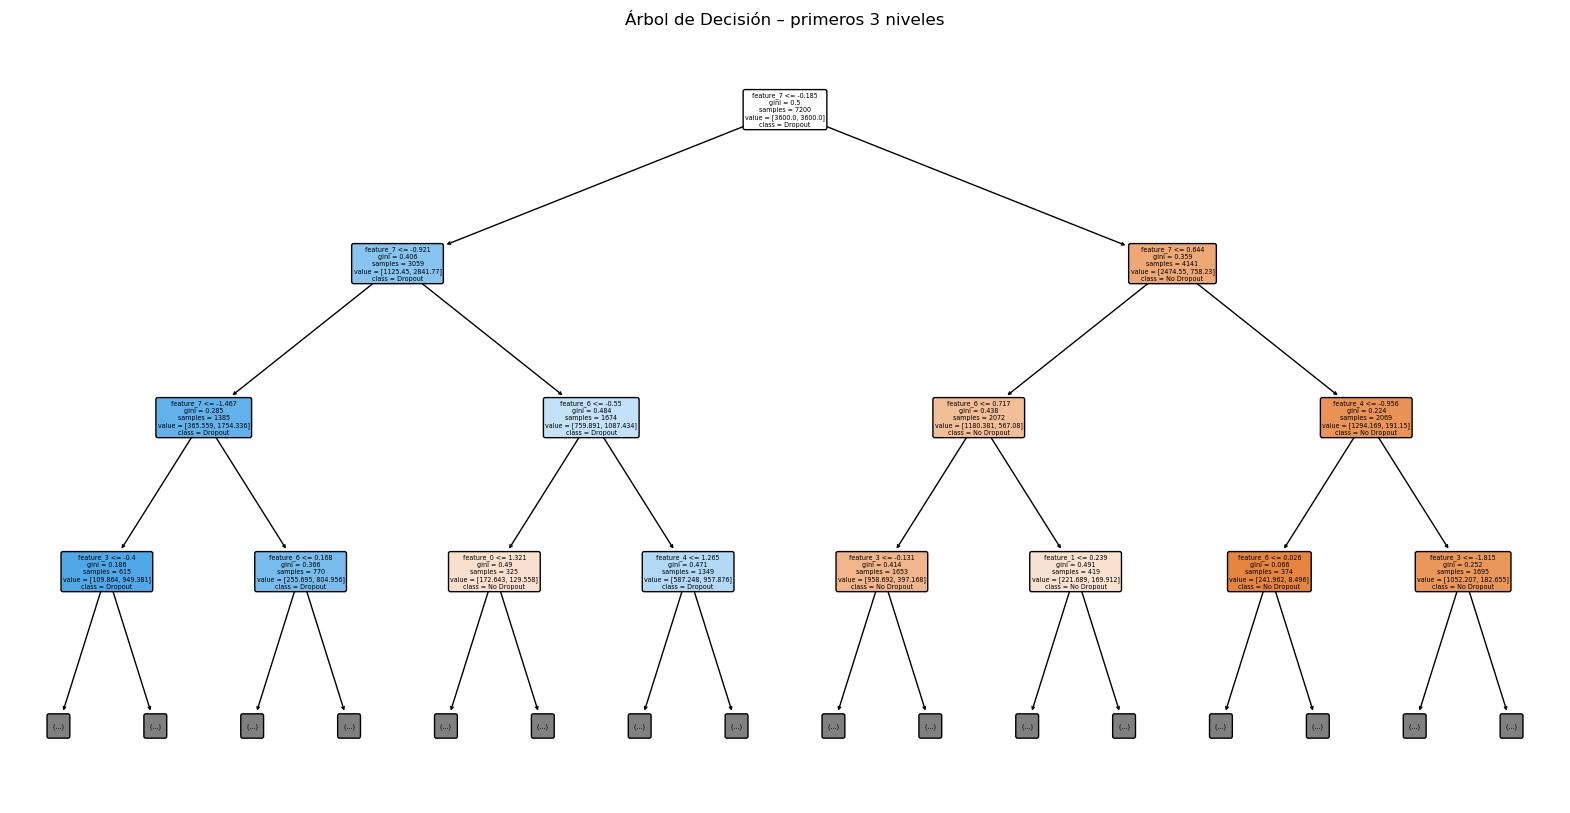

In [60]:
arbol = best_model_dt.named_steps["dt"]

n_features    = arbol.n_features_in_
feature_names = [f"feature_{i}" for i in range(n_features)]

plt.figure(figsize=(20, 10))
tree.plot_tree(
    arbol,
    feature_names=feature_names,
    class_names=["No Dropout", "Dropout"],
    filled=True, rounded=True,
    max_depth=3
)
plt.title("Árbol de Decisión – primeros 3 niveles")
plt.show()


# Comparación KNN vs Árbol de Decisión

Comparamos los dos modelos optimizados y seleccionamos el mejor (`best_model`) para las secciones de análisis posteriores.

In [61]:
# Comparamos las métricas de ambos modelos en validación
resultados_comparacion = pd.DataFrame([
    {
        "Modelo":    "KNN (Grid Search)",
        "PR-AUC":    average_precision_score(y_val, y_val_proba_knn),
        "F1":        f1_score(y_val, y_val_pred_knn, zero_division=0),
        "Recall":    recall_score(y_val, y_val_pred_knn, zero_division=0),
        "Precision": precision_score(y_val, y_val_pred_knn, zero_division=0),
    },
    {
        "Modelo":    "Árbol de Decisión (Grid Search)",
        "PR-AUC":    average_precision_score(y_val, y_val_proba_dt),
        "F1":        f1_score(y_val, y_val_pred_dt, zero_division=0),
        "Recall":    recall_score(y_val, y_val_pred_dt, zero_division=0),
        "Precision": precision_score(y_val, y_val_pred_dt, zero_division=0),
    }
]).sort_values("PR-AUC", ascending=False).round(4)
display(resultados_comparacion)

# Seleccionamos el mejor modelo como referencia para las secciones siguientes
mejor_nombre = resultados_comparacion.iloc[0]["Modelo"]
if "KNN" in mejor_nombre:
    best_model  = best_model_knn
    y_val_pred  = y_val_pred_knn
    y_val_proba = y_val_proba_knn
else:
    best_model  = best_model_dt
    y_val_pred  = y_val_pred_dt
    y_val_proba = y_val_proba_dt

print(f"Mejor modelo seleccionado: {mejor_nombre}")


,Modelo,PR-AUC,F1,Recall,Precision
0,KNN (Grid Search),0.5471,0.3531,0.2453,0.6303
1,Árbol de Decisión (Grid Search),0.5131,0.5456,0.7264,0.4369


Mejor modelo seleccionado: KNN (Grid Search)


# Técnicas de Muestreo para Datos Desbalanceados

Analizamos el impacto de las técnicas de sobre-muestreo y submuestreo usando la mejor configuración de preprocesamiento y los mejores hiperparámetros KNN.

In [62]:
# Comparamos el impacto de las técnicas de muestreo con la mejor configuración
# de preprocesamiento y los mejores hiperparámetros KNN del grid search.

tecnicas_muestreo = {
    "Sin muestreo": None,
    "RUS":          RandomUnderSampler(random_state=42),
    "ROS":          RandomOverSampler(random_state=42),
    "SMOTE":        SMOTE(random_state=42),
    "SMOTETomek":   SMOTETomek(random_state=42),
    "SMOTEENN":     SMOTEENN(random_state=42),
}

# Extraemos los hiperparámetros del mejor KNN (sin el prefijo "knn__")
best_knn_params = {k.replace("knn__", ""): v for k, v in grid_knn.best_params_.items()}

resultados_muestreo = []
for nombre, sampler in tecnicas_muestreo.items():
    # crear_pipeline acepta un sampler opcional; usa ImbPipeline internamente
    pipe = crear_pipeline(config_actual, sampler=sampler)
    pipe.named_steps["knn"].set_params(**best_knn_params)

    pipe.fit(X_train, y_train)
    y_pred  = pipe.predict(X_val)
    y_proba = pipe.predict_proba(X_val)[:, 1]

    resultados_muestreo.append({
        "Técnica":   nombre,
        "PR-AUC":    average_precision_score(y_val, y_proba),
        "F1":        f1_score(y_val, y_pred, zero_division=0),
        "Recall":    recall_score(y_val, y_pred, zero_division=0),
        "Precision": precision_score(y_val, y_pred, zero_division=0),
    })

tabla_muestreo = pd.DataFrame(resultados_muestreo).sort_values("PR-AUC", ascending=False)
display(tabla_muestreo)

# Guardamos la mejor técnica para poder incorporarla al modelo final si mejora
mejor_sampler_nombre = tabla_muestreo.iloc[0]["Técnica"]
mejor_sampler = tecnicas_muestreo[mejor_sampler_nombre]
print(f"Mejor técnica de muestreo: {mejor_sampler_nombre}")


,Técnica,PR-AUC,F1,Recall,Precision
3,SMOTE,0.548745,0.550772,0.799528,0.420074
2,ROS,0.548407,0.547970,0.700472,0.450000
4,SMOTETomek,0.547152,0.551948,0.801887,0.420792
0,Sin muestreo,0.547089,0.353141,0.245283,0.630303
1,RUS,0.532984,0.549860,0.695755,0.454545
5,SMOTEENN,0.532079,0.491656,0.903302,0.337743


Mejor técnica de muestreo: SMOTE


In [72]:
# Si el muestreo mejora, reconstruimos best_model con él
if tabla_muestreo.iloc[0]["PR-AUC"] > average_precision_score(y_val, y_val_proba):
    pipe_final = crear_pipeline(config_actual, sampler=mejor_sampler)
    pipe_final.named_steps["knn"].set_params(**best_knn_params)
    pipe_final.fit(X_train, y_train)
    best_model  = pipe_final
    y_val_pred  = best_model.predict(X_val)
    y_val_proba = best_model.predict_proba(X_val)[:, 1]
    print(f"Modelo actualizado con muestreo: {mejor_sampler_nombre}")

Modelo actualizado con muestreo: SMOTE


# Eliminación de ruido

In [63]:
# Aplicamos técnicas de eliminación de ruido sobre los datos preprocesados de entrenamiento.
# Evaluamos el efecto entrenando el mejor KNN sobre los datos limpios.

preprocessor_fit = best_model.named_steps["preprocessor"]
X_train_proc     = preprocessor_fit.transform(X_train)
X_val_proc       = preprocessor_fit.transform(X_val)

best_knn_params  = {k.replace("knn__", ""): v for k, v in grid_knn.best_params_.items()}

resultados_ruido = []
for nombre, tecnica in [
    ("Sin eliminación",  None),
    ("TomekLinks",       TomekLinks(sampling_strategy="all")),
    ("ENN",              EditedNearestNeighbours(sampling_strategy="all", kind_sel="mode")),
    ("AllKNN",           AllKNN(sampling_strategy="all")),
]:
    if tecnica is None:
        X_clean, y_clean = X_train_proc, y_train
    else:
        X_clean, y_clean = tecnica.fit_resample(X_train_proc, y_train)

    n_elim       = len(X_train_proc) - len(X_clean)
    distribucion = pd.Series(y_clean).value_counts().to_dict()
    print(f"{nombre}: {n_elim} ejemplos eliminados | Distribución: {distribucion}")

    # Entrenamos directamente el KNN sobre los datos ya preprocesados y limpios
    knn_clean = KNeighborsClassifier(**best_knn_params)
    knn_clean.fit(X_clean, y_clean)

    y_pred  = knn_clean.predict(X_val_proc)
    y_proba = knn_clean.predict_proba(X_val_proc)[:, 1]

    resultados_ruido.append({
        "Técnica":             nombre,
        "Ejemplos eliminados": n_elim,
        "PR-AUC":              average_precision_score(y_val, y_proba),
        "F1":                  f1_score(y_val, y_pred, zero_division=0),
        "Recall":              recall_score(y_val, y_pred, zero_division=0),
        "Precision":           precision_score(y_val, y_pred, zero_division=0),
    })

tabla_ruido = pd.DataFrame(resultados_ruido).sort_values("PR-AUC", ascending=False)
display(tabla_ruido)


Sin eliminación: 0 ejemplos eliminados | Distribución: {0: 5505, 1: 1695}
TomekLinks: 688 ejemplos eliminados | Distribución: {0: 5161, 1: 1351}
ENN: 1720 ejemplos eliminados | Distribución: {0: 4902, 1: 578}
AllKNN: 2831 ejemplos eliminados | Distribución: {0: 4231, 1: 138}


,Técnica,Ejemplos eliminados,PR-AUC,F1,Recall,Precision
1,TomekLinks,688,0.548423,0.353141,0.245283,0.630303
0,Sin eliminación,0,0.547089,0.353141,0.245283,0.630303
2,ENN,1720,0.536182,0.235067,0.143868,0.642105
3,AllKNN,2831,0.460190,0.096703,0.051887,0.709677


In [73]:
# Si eliminar ruido mejora, guardamos los índices limpios para reentrenar
mejor_ruido = tabla_ruido.iloc[0]["Técnica"]
if mejor_ruido != "Sin eliminación":
    tecnica_ruido = dict([
        ("TomekLinks", TomekLinks(sampling_strategy="all")),
        ("ENN",        EditedNearestNeighbours(sampling_strategy="all", kind_sel="mode")),
        ("AllKNN",     AllKNN(sampling_strategy="all"))
    ])[mejor_ruido]
    X_clean, y_clean = tecnica_ruido.fit_resample(X_train_proc, y_train)
    knn_final = KNeighborsClassifier(**best_knn_params)
    knn_final.fit(X_clean, y_clean)
    pr_ruido = average_precision_score(y_val, knn_final.predict_proba(X_val_proc)[:, 1])
    if pr_ruido > average_precision_score(y_val, y_val_proba):
        y_val_pred  = knn_final.predict(X_val_proc)
        y_val_proba = knn_final.predict_proba(X_val_proc)[:, 1]
        print(f"Modelo actualizado con ruido: {mejor_ruido}")

## Métricas de rendimiento  
* Métricas dependientes del umbral: matriz de confusión

In [74]:
matriz_confusion = confusion_matrix(y_val, y_val_pred)

print("Matriz de confusión:")
print(matriz_confusion)
print()
print("Accuracy:", np.round(accuracy_score(y_val, y_val_pred) * 100, 2)) # habria que quitar
print("Precision:", np.round(precision_score(y_val, y_val_pred, pos_label=1) * 100, 2))
print("Recall:", np.round(recall_score(y_val, y_val_pred, pos_label=1) * 100, 2))
print("F1:", np.round(f1_score(y_val, y_val_pred, pos_label=1) * 100, 2))
print()
print(classification_report(y_val, y_val_pred))   

# antes de generacionvariables y log:
"""Matriz de confusión:
[[1283   93]
 [ 273  151]]

Accuracy: 79.67
Precision: 61.89
Recall: 35.61
F1: 45.21"""

Matriz de confusión:
[[908 468]
 [ 85 339]]

Accuracy: 69.28
Precision: 42.01
Recall: 79.95
F1: 55.08

              precision    recall  f1-score   support

           0       0.91      0.66      0.77      1376
           1       0.42      0.80      0.55       424

    accuracy                           0.69      1800
   macro avg       0.67      0.73      0.66      1800
weighted avg       0.80      0.69      0.72      1800



'Matriz de confusión:\n[[1283   93]\n [ 273  151]]\n\nAccuracy: 79.67\nPrecision: 61.89\nRecall: 35.61\nF1: 45.21'

* Métricas independientes del umbral: curvas ROC y PR

In [75]:

precision_curve, recall_curve, umbrales_pr = precision_recall_curve(y_val, y_val_proba, pos_label=1)
pr_auc = auc(recall_curve, precision_curve)

print("PR-AUC:", pr_auc)

PR-AUC: 0.5477985173340602


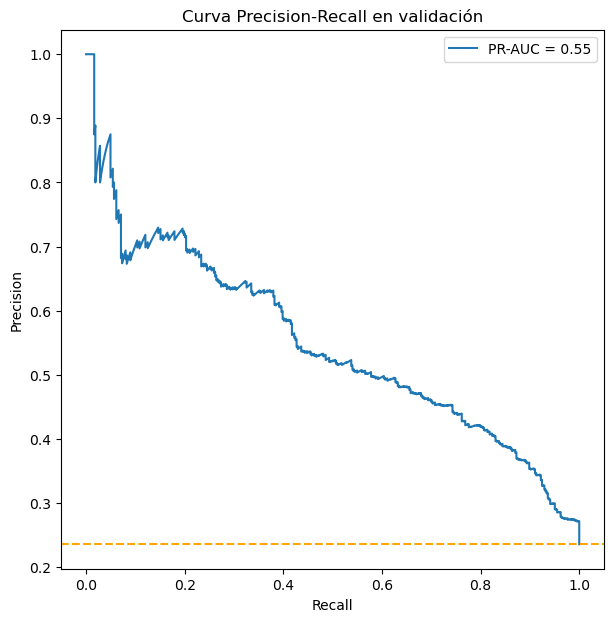

In [76]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7,7))

ratio_positivos = y_val.mean()
plt.plot(recall_curve, precision_curve, label=f"PR-AUC = {pr_auc:.2f}")
plt.axhline(y=y_val.mean(), linestyle="--", color="orange")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall en validación")
plt.legend()

plt.show()

In [77]:
umbrales = np.arange(0.10, 1.00, 0.05)

resultados_umbral = []

for umbral in umbrales:
    y_val_umbral = (y_val_proba >= umbral).astype(int)
    acc = accuracy_score(y_val, y_val_umbral)
    prec = precision_score(y_val, y_val_umbral, pos_label=1)
    rec = recall_score(y_val, y_val_umbral, pos_label=1)
    f1 = f1_score(y_val, y_val_umbral, pos_label=1)
    resultados_umbral.append([umbral, acc, prec, rec, f1])

tabla_umbral = pd.DataFrame(resultados_umbral, columns=["umbral", "accuracy", "precision", "recall", "f1"])
tabla_umbral

,umbral,accuracy,precision,recall,f1
0,0.10,0.318889,0.256970,1.000000,0.408872
1,0.15,0.346667,0.265000,1.000000,0.418972
2,0.20,0.396111,0.276467,0.966981,0.429995
3,0.25,0.451667,0.294375,0.950472,0.449526
4,0.30,0.505556,0.315079,0.936321,0.471496
5,0.35,0.567778,0.343915,0.919811,0.500642
6,0.40,0.611111,0.366019,0.889151,0.518569
7,0.45,0.657222,0.393134,0.837264,0.535041
8,0.50,0.692778,0.420074,0.799528,0.550772
9,0.55,0.715556,0.439058,0.747642,0.553229


In [78]:
mejor_f1 = tabla_umbral.loc[tabla_umbral["f1"].idxmax()]
umbral_optimo = np.round(mejor_f1["umbral"], 2)

print("Mejor fila según F1:")
print(mejor_f1)
print()
print("Umbral óptimo:", umbral_optimo)

"""Mejor fila según F1:  # antes de generacion vars y log
umbral       0.200000
accuracy     0.713889
precision    0.437068
recall       0.745283
f1           0.551003
Name: 2, dtype: float64

Umbral óptimo: 0.2"""

Mejor fila según F1:
umbral       0.550000
accuracy     0.715556
precision    0.439058
recall       0.747642
f1           0.553229
Name: 9, dtype: float64

Umbral óptimo: 0.55


'Mejor fila según F1:  # antes de generacion vars y log\numbral       0.200000\naccuracy     0.713889\nprecision    0.437068\nrecall       0.745283\nf1           0.551003\nName: 2, dtype: float64\n\nUmbral óptimo: 0.2'

# Rendimiento en test

In [79]:
y_test_proba = best_model.predict_proba(X_test)[:,1]
y_test_pred = (y_test_proba >= umbral_optimo).astype(int)

matriz_confusion_test = confusion_matrix(y_test,y_test_pred)

print("Matriz de confusión en test:")
print(matriz_confusion_test)
print()
print("Accuracy:", np.round(accuracy_score(y_test, y_test_pred) * 100, 2))
print("Precision:", np.round(precision_score(y_test, y_test_pred) * 100, 2))
print("Recall:", np.round(recall_score(y_test, y_test_pred) * 100, 2))
print("F1:", np.round(f1_score(y_test, y_test_pred) * 100, 2))

precision_test, recall_test, _ = precision_recall_curve(y_test, y_test_proba, pos_label=1)
pr_auc_test = np.round(auc(recall_test, precision_test)* 100, 2)
print("PR-AUC:", pr_auc_test)

Matriz de confusión en test:
[[517 248]
 [ 72 163]]

Accuracy: 68.0
Precision: 39.66
Recall: 69.36
F1: 50.46
PR-AUC: 50.22


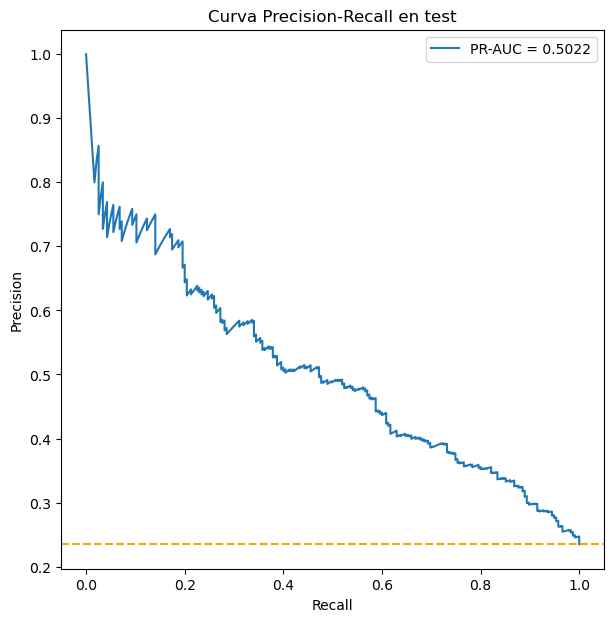

In [80]:
precision_test, recall_test, _ = precision_recall_curve(y_test, y_test_proba, pos_label=1)

plt.figure(figsize=(7,7))

ratio_positivos = y_test.mean()
plt.plot(recall_test, precision_test, label=f"PR-AUC = {auc(recall_test, precision_test):.4f}")
plt.axhline(y=y_test.mean(), linestyle="--", color="orange")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall en test")
plt.legend()

plt.show()

Objetivo:  
evitar dropouts, evitar alumno que va a abandonar y no detectar (falso negativo)  
Maximizar recall, f1, pr